# Layer Dashboard

이 노트북은 5개 레이어 테이블(child/safety/nature/landmark/running)의 규모·중복·raw 구성·자치구 분포를 점검한다.

확인 질문:

- 레이어 간 데이터 규모는 얼마나 편중되어 있는가?
- 레이어 내 중복 행은 없는가?
- 각 레이어는 어떤 raw 소스에서 유입되는가?
- 레이어 데이터는 자치구별로 고르게 분포하는가?
- 레이어 내 빈도 상위 항목은 무엇인가?

## 0. 실행 환경

### 주피터 노트북 실행환경

1. 분석 환경 의존성 추가

    ```
    poetry lock
    poetry install --with analysis
    ```

2. 이후 Jupyter 커널 등록

    ```
    poetry run python -m ipykernel install --user --name seoul-walk --display-name "seoul-walk (Poetry)"
    ```

3. jupyter notebook 세션 선택 시 poetry venv 경로로 선택

In [34]:
# jupyter notebook 세션 확인하기
# Poetry venv 경로가 나오면 정상
import sys
print(sys.executable)

c:\Users\dygim\AppData\Local\pypoetry\Cache\virtualenvs\seoul-walk-platform-D_JI-aCK-py3.11\Scripts\python.exe


In [35]:
# Setup

# 분석에 필요한 라이브러리 불러오기
import os, sys

# 프로젝트 루트를 sys.path에 추가해 src 패키지 import
sys.path.insert(0, os.path.abspath("../"))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# 한글 폰트 설정 및 '-' 기호 깨짐 방지
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# .env에서 DB 접속 정보 로드
load_dotenv(encoding="utf-8")
DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}?client_encoding=utf8"
)
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

# 분석 결과 이미지 저장 디렉토리 (raw 대시보드와 동일하게 노트북별 서브폴더 사용)
FIGURES_DIR = "../figures/layer"
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. 레이어별 총 개수

In [36]:
# 레이어별 총 개수

# 5개 레이어 테이블 각각의 전체 row 수를 UNION ALL로 한번에 집계
# 레이어 간 데이터 규모 차이 파악 → 비율 계산과 시각화의 기반 데이터
# UNION ALL은 여러 SELECT 결과를 그대로 이어붙이는 역할
layer_count_sql = """
SELECT layer, count FROM (
    SELECT 'child_layer'    AS layer, COUNT(*) AS count FROM child_layer    UNION ALL
    SELECT 'safety_layer'   AS layer, COUNT(*) AS count FROM safety_layer   UNION ALL
    SELECT 'nature_layer'   AS layer, COUNT(*) AS count FROM nature_layer   UNION ALL
    SELECT 'landmark_layer' AS layer, COUNT(*) AS count FROM landmark_layer UNION ALL
    SELECT 'running_layer'  AS layer, COUNT(*) AS count FROM running_layer
) t ORDER BY count DESC
"""
layer_counts = pd.read_sql(text(layer_count_sql), engine)
layer_counts

,layer,count
0,safety_layer,45148
1,child_layer,8249
2,nature_layer,6516
3,landmark_layer,658
4,running_layer,225


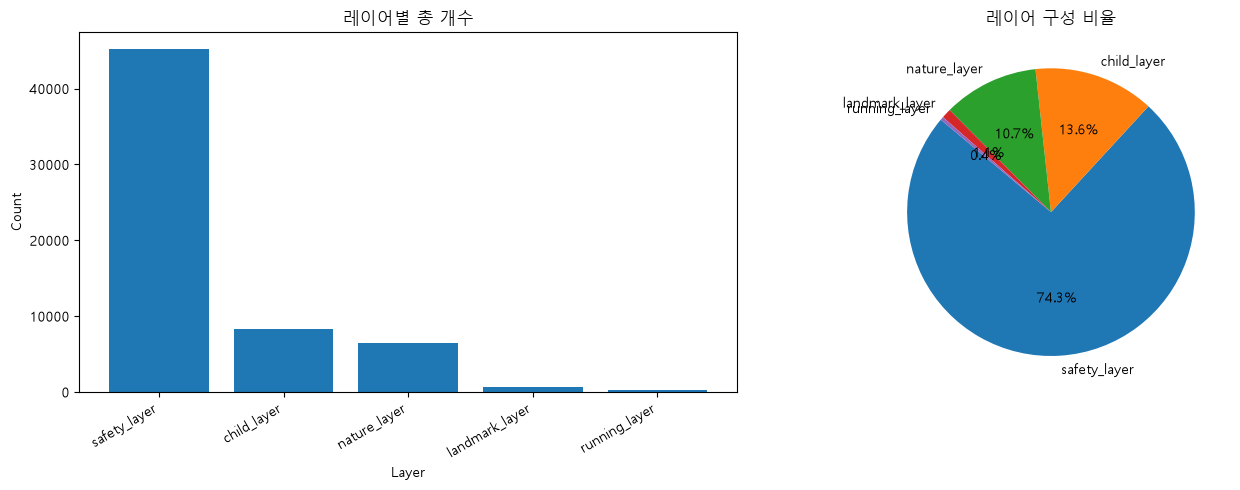

In [37]:
# 레이어별 총 개수 막대그래프 + 파이차트

# 위에서 집계한 결과의 시각화 버전
# 레이어 간 데이터 편중 여부 파악 가능
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대그래프
axes[0].bar(layer_counts["layer"], layer_counts["count"])
axes[0].set_title("레이어별 총 개수")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Count")
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# 파이차트
axes[1].pie(layer_counts["count"], labels=layer_counts["layer"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("레이어 구성 비율")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_count_and_ratio.png", dpi=150)
plt.show()

## 2. 레이어 내 중복 탐지

In [38]:
# 중복 탐지

# 각 레이어에서 key 컬럼(이름+좌표 또는 타입+FK) 조합이 중복된 행 검색
dup_queries = {
    "child_layer":    "SELECT category, ST_AsText(geom) g, COUNT(*) cnt FROM child_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "safety_layer":   "SELECT safety_type, ST_AsText(geom) g, COUNT(*) cnt FROM safety_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "nature_layer":   "SELECT green_type, osm_raw_id, COUNT(*) cnt FROM nature_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "landmark_layer": "SELECT name, ST_AsText(geom) g, COUNT(*) cnt FROM landmark_layer GROUP BY 1,2 HAVING COUNT(*)>1",
    "running_layer":  "SELECT name, course_type, COUNT(*) cnt FROM running_layer GROUP BY 1,2 HAVING COUNT(*)>1",
}

dup_summary = []
for layer, sql in dup_queries.items():
    df = pd.read_sql(text(sql), engine)
    dup_summary.append({
        "layer": layer,
        "중복 그룹 수": len(df),
        "중복 행 수": int(df["cnt"].sum()) if len(df) > 0 else 0,
    })

pd.DataFrame(dup_summary)

,layer,중복 그룹 수,중복 행 수
0,child_layer,7,14
1,safety_layer,0,0
2,nature_layer,0,0
3,landmark_layer,0,0
4,running_layer,6,21


## 3. raw 범주별 분포

In [39]:
# raw 범주별 분포

# 각 layer row가 어떤 raw 소스에서 유입됐는지 FK 기준으로 집계
# child_layer: csv_raw vs public_raw
child_raw = pd.read_sql(text("""
    SELECT CASE WHEN csv_raw_id IS NOT NULL THEN 'csv_raw(보호구역)'
                WHEN public_raw_id IS NOT NULL THEN 'public_raw(놀이시설)'
                ELSE 'unknown' END AS raw_source,
           COUNT(*) AS count
    FROM child_layer GROUP BY 1
"""), engine)
child_raw["layer"] = "child_layer"

# safety_layer: safety_type으로 구분
safety_raw = pd.read_sql(text("""
    SELECT safety_type AS raw_source, COUNT(*) AS count
    FROM safety_layer GROUP BY 1
"""), engine)
safety_raw["layer"] = "safety_layer"

# nature_layer: 전부 osm_raw, green_type으로 구분
nature_raw = pd.read_sql(text("""
    SELECT COALESCE(green_type, 'unknown') AS raw_source, COUNT(*) AS count
    FROM nature_layer GROUP BY 1 ORDER BY count DESC
"""), engine)
nature_raw["layer"] = "nature_layer"

# running_layer: course_type으로 구분
running_raw = pd.read_sql(text("""
    SELECT course_type AS raw_source, COUNT(*) AS count
    FROM running_layer GROUP BY 1
"""), engine)
running_raw["layer"] = "running_layer"

# landmark_layer: raw FK 없음 — TourAPI 단일 소스
landmark_raw = pd.DataFrame([{"raw_source": "public_raw(TourAPI)", "count": layer_counts.loc[layer_counts["layer"]=="landmark_layer","count"].values[0], "layer": "landmark_layer"}])

raw_dist = pd.concat([child_raw, safety_raw, nature_raw, running_raw, landmark_raw], ignore_index=True)
raw_dist

,raw_source,count,layer
0,csv_raw(보호구역),1184,child_layer
1,public_raw(놀이시설),7065,child_layer
2,accident_zone,132,safety_layer
3,cctv,44711,safety_layer
4,streetlight,305,safety_layer
5,park,2205,nature_layer
6,grass,1714,nature_layer
7,wood,1011,nature_layer
8,garden,955,nature_layer
9,forest,394,nature_layer


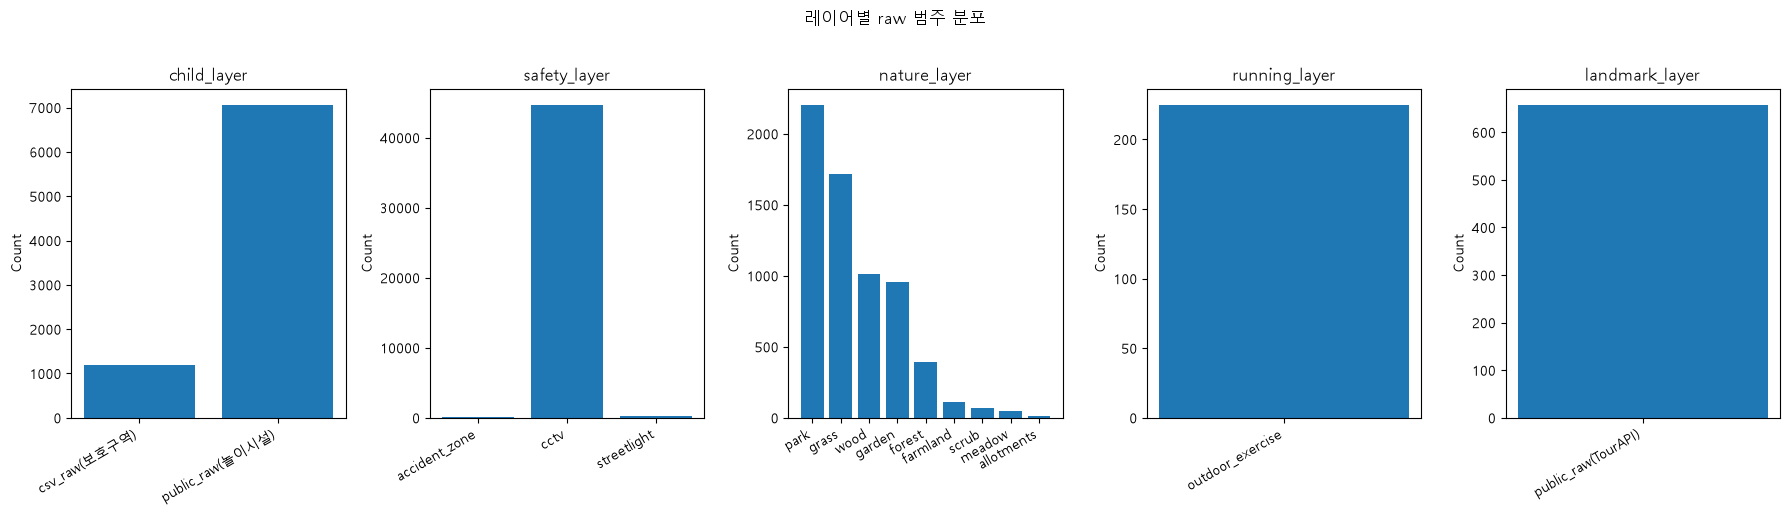

In [40]:
# raw 범주별 분포 시각화

# 위에서 집계한 결과를 시각화
layers = raw_dist["layer"].unique()
fig, axes = plt.subplots(1, len(layers), figsize=(18, 5))

for ax, layer in zip(axes, layers):
    df = raw_dist[raw_dist["layer"] == layer]
    ax.bar(df["raw_source"], df["count"])
    ax.set_title(layer)
    ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("레이어별 raw 범주 분포", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_raw_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### running_layer 데이터 상태 안내

`running_layer`는 현재 `outdoor_exercise` 225건만 존재한다. `RunningCourseCollector().save()`가 `data_collector.py`에서 주석 처리되어 있어 공원(`park`)·자전거도로(`bike_track`)·하천(`river`)·둘레길(`trail`) 코스는 아직 적재되지 않았다. 활성화 여부는 팀 확인이 필요한 별도 사항이며, 이 노트북의 `running_layer` 관련 수치는 모두 이 상태를 반영한 결과다.

## 4. 자치구(구)별 레이어 분포

레이어 테이블에는 구 컬럼이 없어, raw 테이블(`csv_raw`/`public_raw`)의 `properties->>'address'`에서 정규식으로 구를 추출한다.

**커버리지 한계**
- `nature_layer`(OSM)는 원본에 한국어 주소 필드가 없어 제외한다.
- `landmark_layer`(TourAPI)는 raw FK를 저장하지 않아(테이블에 public_raw_id 컬럼 없음) 제외한다.
- `safety_layer`의 `accident_zone`, `running_layer`의 `outdoor_exercise`는 raw FK가 없어 "구 미상"으로 집계된다.

In [41]:
import re

SEOUL_GU = {
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
}

def extract_gu(address):
    if address is None:
        return "구 미상"
    match = re.search(r"([가-힣]+구)", str(address))
    return match.group(1) if match and match.group(1) in SEOUL_GU else "구 미상"

gu_queries = {
    "child_layer": """
        SELECT COALESCE(cr.properties->>'address', pr.properties->>'address') AS address
        FROM child_layer cl
        LEFT JOIN csv_raw cr ON cl.csv_raw_id = cr.id
        LEFT JOIN public_raw pr ON cl.public_raw_id = pr.id
    """,
    "safety_layer": """
        SELECT cr.properties->>'address' AS address
        FROM safety_layer sl
        LEFT JOIN csv_raw cr ON sl.csv_raw_id = cr.id
    """,
    "running_layer": """
        SELECT cr.properties->>'address' AS address
        FROM running_layer rl
        LEFT JOIN csv_raw cr ON rl.csv_raw_id = cr.id
    """,
}

gu_rows = []
for layer, sql in gu_queries.items():
    df = pd.read_sql(text(sql), engine)
    df["gu"] = df["address"].map(extract_gu)
    counts = df["gu"].value_counts().reset_index()
    counts.columns = ["gu", "count"]
    counts["layer"] = layer
    gu_rows.append(counts)

gu_dist = pd.concat(gu_rows, ignore_index=True)
gu_pivot = gu_dist.pivot_table(index="gu", columns="layer", values="count", fill_value=0)
gu_pivot = gu_pivot.reindex(sorted(gu_pivot.index, key=lambda g: (g == "구 미상", g)))
gu_pivot

layer,child_layer,running_layer,safety_layer
gu,,,
강남구,469.0,0.0,2530.0
강동구,377.0,0.0,1.0
강북구,157.0,0.0,1490.0
강서구,404.0,0.0,1989.0
관악구,356.0,0.0,500.0
광진구,240.0,0.0,177.0
구로구,363.0,0.0,2148.0
금천구,199.0,0.0,0.0
노원구,547.0,0.0,1845.0


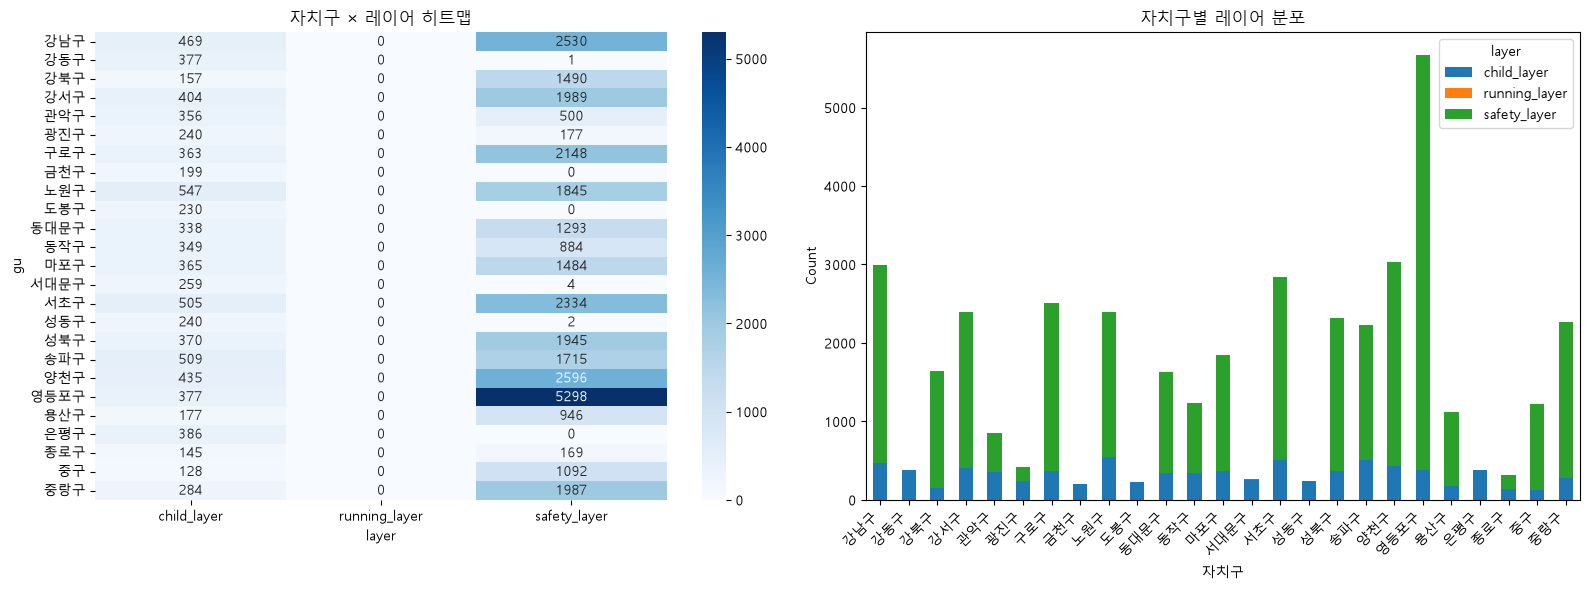

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

gu_pivot_known = gu_pivot.drop(index="구 미상", errors="ignore")

sns.heatmap(gu_pivot_known, annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
axes[0].set_title("자치구 × 레이어 히트맵")

gu_pivot_known.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("자치구별 레이어 분포")
axes[1].set_xlabel("자치구")
axes[1].set_ylabel("Count")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_gu_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. raw × layer 크로스탭

현재 `source_collector.py`와 `data_collector.py`에 연결된 데이터셋을 기준으로 raw와 layer 관계를 비교한다.

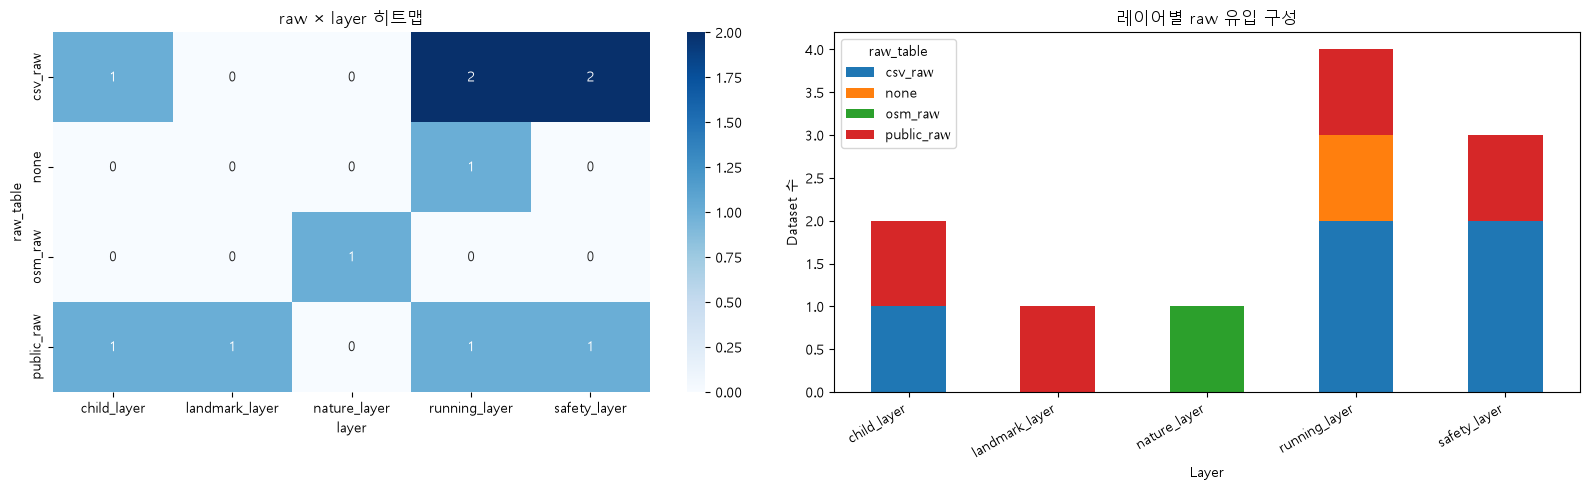

In [43]:
# raw × layer 크로스탭 (현재 실행 코드 기준)
active_mappings = pd.DataFrame([
    {"dataset": "osm_green_area", "raw_table": "osm_raw", "layer": "nature_layer"},
    {"dataset": "streetlight", "raw_table": "csv_raw", "layer": "safety_layer"},
    {"dataset": "cctv", "raw_table": "csv_raw", "layer": "safety_layer"},
    {"dataset": "protection_zone", "raw_table": "csv_raw", "layer": "child_layer"},
    {"dataset": "play_facility", "raw_table": "public_raw", "layer": "child_layer"},
    {"dataset": "landmark", "raw_table": "public_raw", "layer": "landmark_layer"},
    {"dataset": "accident_zone", "raw_table": "public_raw", "layer": "safety_layer"},
    {"dataset": "outdoor_exercise", "raw_table": "public_raw", "layer": "running_layer"},
])
crosstab = pd.crosstab(active_mappings["raw_table"], active_mappings["layer"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히트맵
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("raw × layer 히트맵")

# 누적 막대그래프
crosstab.T.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("레이어별 raw 유입 구성")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Dataset 수")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/raw_layer_crosstab.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 레이어 내 빈도 상위 N개 항목


▶ child_layer(category)


,item,cnt
0,어린이놀이시설,7065
1,어린이보호구역,1184



▶ safety_layer(safety_type)


,item,cnt
0,cctv,44711
1,streetlight,305
2,accident_zone,132



▶ nature_layer(green_type)


,item,cnt
0,park,2205
1,grass,1714
2,wood,1011
3,garden,955
4,forest,394
5,farmland,111
6,scrub,70
7,meadow,46
8,allotments,10



▶ running_layer(course_type)


,item,cnt
0,outdoor_exercise,225


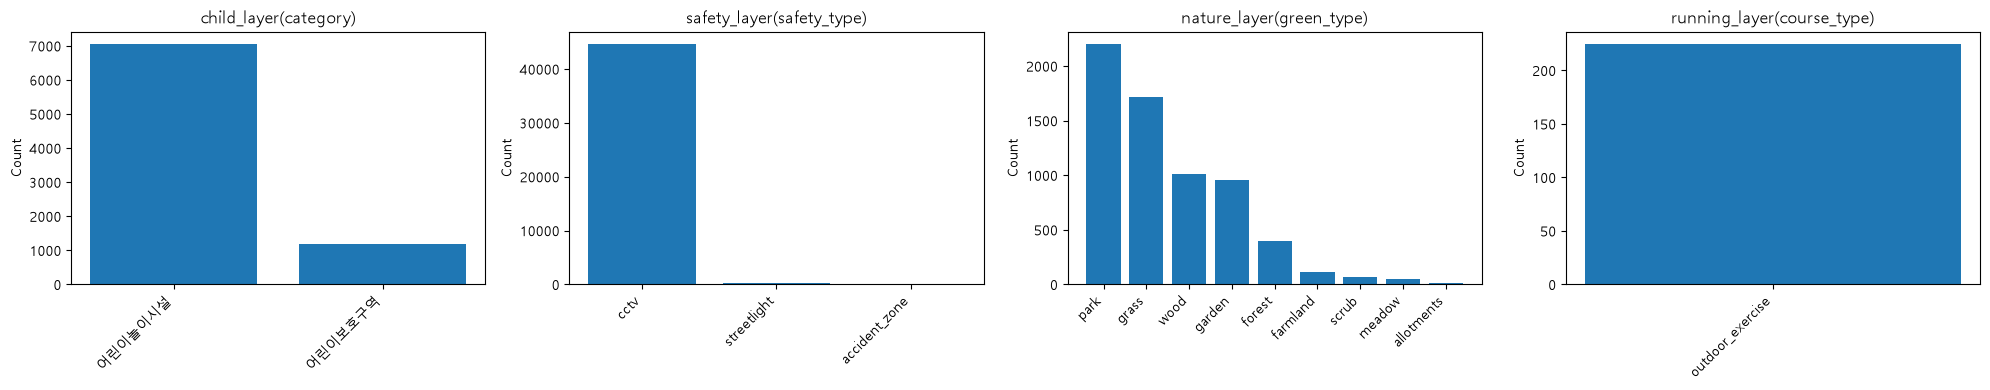

In [44]:
# 레이어 내 빈도 상위 N개 항목

TOP_N = 10

top_queries = {
    "child_layer(category)":     "SELECT category AS item, COUNT(*) cnt FROM child_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "safety_layer(safety_type)": "SELECT safety_type AS item, COUNT(*) cnt FROM safety_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "nature_layer(green_type)":  "SELECT COALESCE(green_type,'unknown') AS item, COUNT(*) cnt FROM nature_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
    "running_layer(course_type)":"SELECT course_type AS item, COUNT(*) cnt FROM running_layer GROUP BY 1 ORDER BY cnt DESC LIMIT {}".format(TOP_N),
}

fig, axes = plt.subplots(1, len(top_queries), figsize=(5 * len(top_queries), 4))

for ax, (title, sql) in zip(axes, top_queries.items()):
    df = pd.read_sql(text(sql), engine)
    print(f"\n▶ {title}")
    display(df)
    ax.bar(df["item"], df["cnt"])
    ax.set_title(title)
    ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/layer_top_n.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. 다음 단계

- V1에 새 데이터를 연결할 때는 `analysis/data-governance/README.md`의 실행 상태 표와 이 노트북의 `active_mappings`를 함께 갱신한다.
- RunningCourseCollector().save() 활성화 여부를 팀과 확인하고, 활성화 시 running_layer 관련 섹션을 재실행한다.
- nature_layer(OSM), landmark_layer(TourAPI)의 자치구 breakdown을 위해 서울 자치구 경계 polygon을 확보하고 ST_Within 기반 spatial join으로 전환한다.
- SafetyCollector.build_accident_records()가 public_raw_id를 채우지만 safety_layer 테이블/엔티티에 해당 컬럼이 없어 보인다 — 스키마 확인이 필요하다.